# 03 - Phân tích đa biến (Multivariate)
**Phụ trách: Nguyễn Xuân Hậu Thành (TV3)**.

In [1]:
import sys; sys.path.append('../src')
from eda_utils import *
train, test = load()
print(train.shape, test.shape)

(1460, 81) (1459, 80)


In [2]:
feat = [c for c in train.columns if c not in ('Id','SalePrice')]
numf = [c for c in feat if str(train[c].dtype)[:3] in ('int','flo')]
cats = [c for c in feat if c not in numf]
cor = train[numf + ['SalePrice']].corr()
cs = cor.SalePrice.drop('SalePrice').sort_values(ascending=False)
sp = train[numf + ['SalePrice']].corr(method='spearman').SalePrice.drop('SalePrice')

## 1. Tương quan với SalePrice

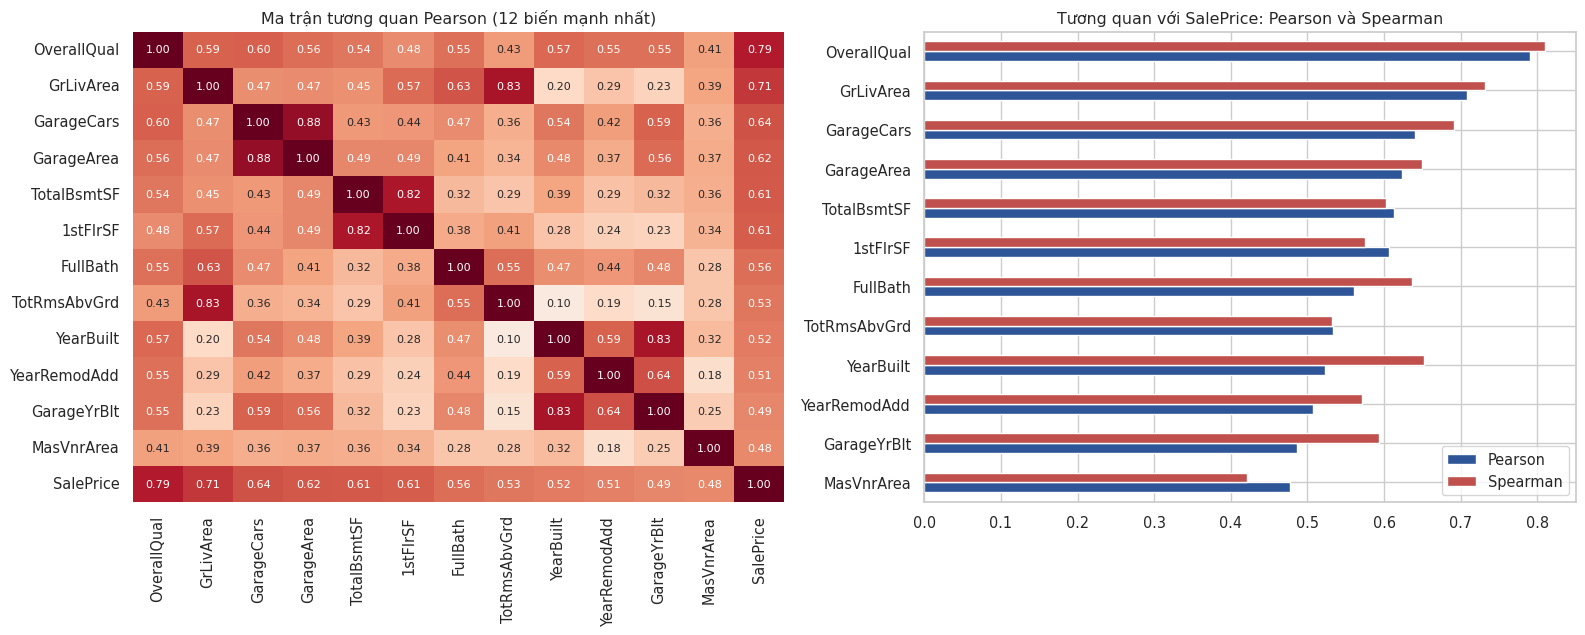

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Âm mạnh nhất:
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136


In [3]:
top = cs.abs().sort_values(ascending=False).head(12).index.tolist()
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
sns.heatmap(train[top + ['SalePrice']].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax[0], annot_kws={'size': 8}, cbar=False)
ax[0].set_title('Ma trận tương quan Pearson (12 biến mạnh nhất)')
t = pd.DataFrame({'Pearson': cs, 'Spearman': sp.reindex(cs.index)}).loc[top].sort_values('Pearson')
t.plot.barh(ax=ax[1], color=['#2E5597', '#C0504D']); ax[1].set_title('Tương quan với SalePrice: Pearson và Spearman')
save_fig('03_tuong_quan')
print(cs.head(10).round(3).to_string()); print('Âm mạnh nhất:'); print(cs.tail(3).round(3).to_string())

## 2. Đa cộng tuyến

Cặp |r| > 0.8: [('GarageCars', 'GarageArea', np.float64(0.882)), ('YearBuilt', 'GarageYrBlt', np.float64(0.826)), ('GrLivArea', 'TotRmsAbvGrd', np.float64(0.825)), ('TotalBsmtSF', '1stFlrSF', np.float64(0.82))]


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stat

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


BsmtFinSF1      1.000800e+15
BsmtUnfSF       1.000800e+15
BsmtFinSF2      1.000800e+15
LowQualFinSF    1.000800e+15
2ndFlrSF        1.000800e+15
1stFlrSF        1.000800e+15
GrLivArea       1.000800e+15
TotalBsmtSF     1.000800e+15
GarageCars      5.500000e+00
GarageArea      5.200000e+00


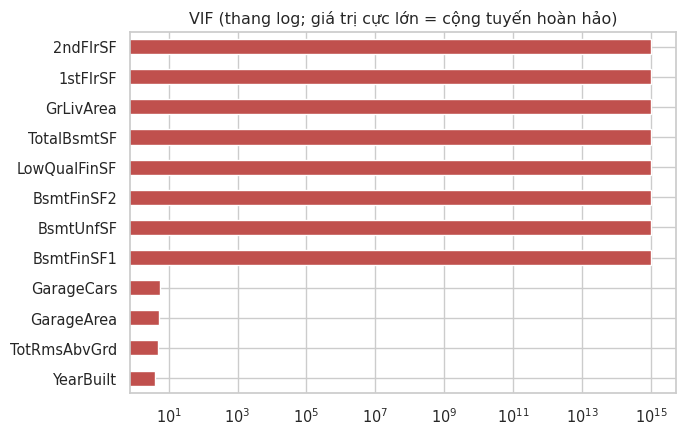

In [4]:
cf = train[numf].corr().abs(); pairs = []
cols = cf.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if cf.iloc[i, j] > 0.8: pairs.append((cols[i], cols[j], round(train[cols[i]].corr(train[cols[j]]), 3)))
pairs = sorted(pairs, key=lambda p: -abs(p[2])); print('Cặp |r| > 0.8:', pairs)
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
X = train[numf].fillna(train[numf].median()); X = X.loc[:, X.std() > 0]; X = X.drop(columns=['GarageYrBlt'], errors='ignore'); X.insert(0, 'const', 1.0)
V = pd.Series({c: vif(X.values, i) for i, c in enumerate(X.columns) if c != 'const'}).sort_values(ascending=False)
print(V.head(10).round(1).to_string())
V.head(12).replace(np.inf, 1e16).sort_values().plot.barh(figsize=(7, 4.5), color='#C0504D', logx=True, title='VIF (thang log; giá trị cực lớn = cộng tuyến hoàn hảo)')
save_fig('03_vif')

## 3. Quan hệ tuyến tính / phi tuyến với giá

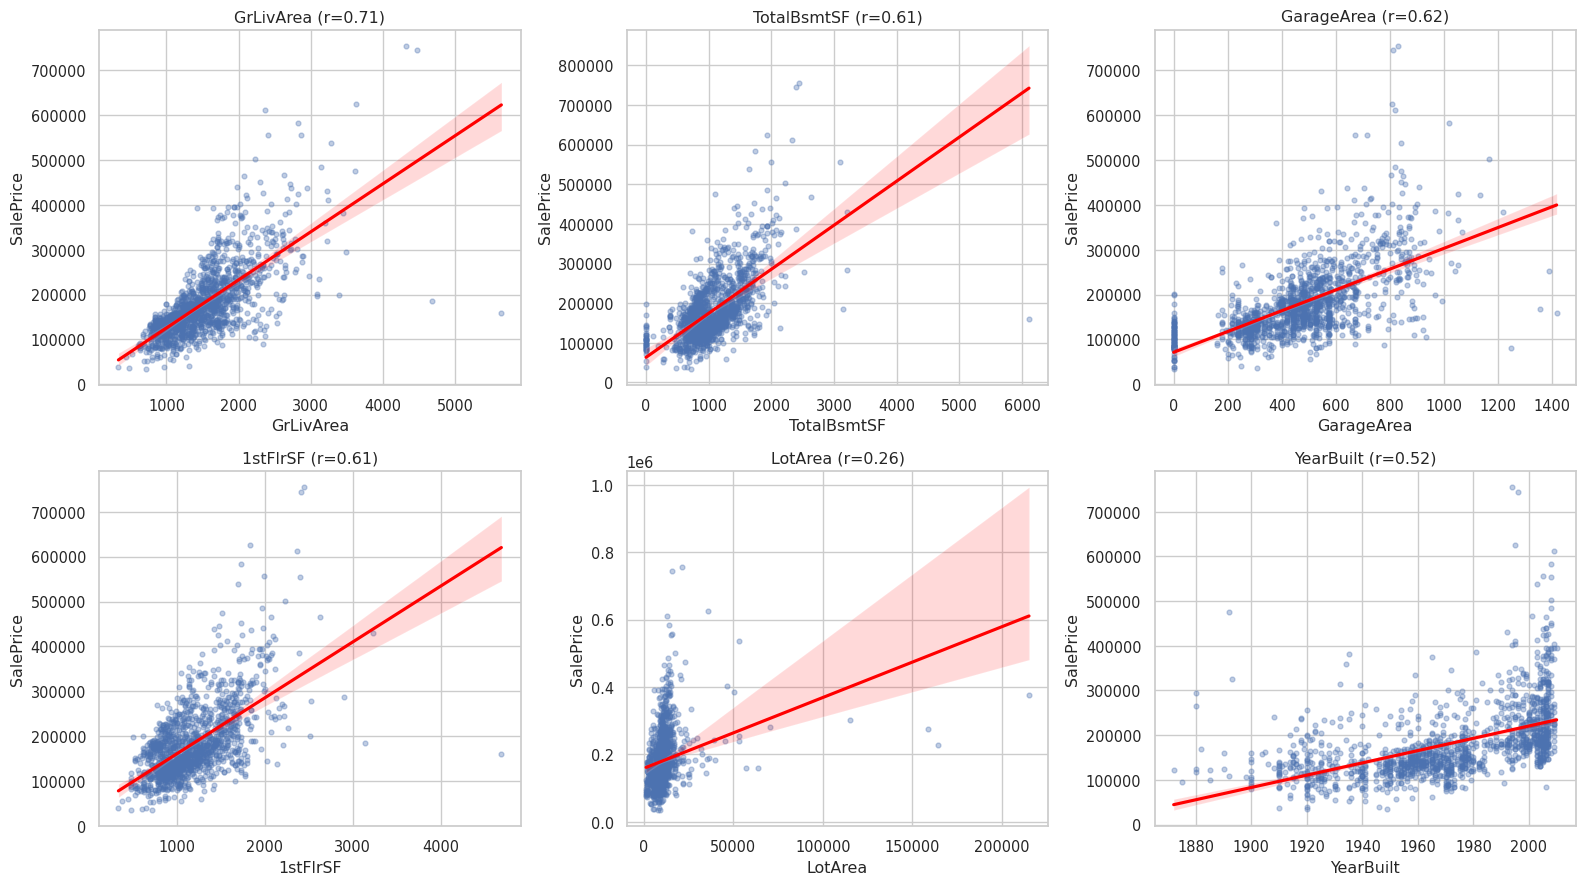

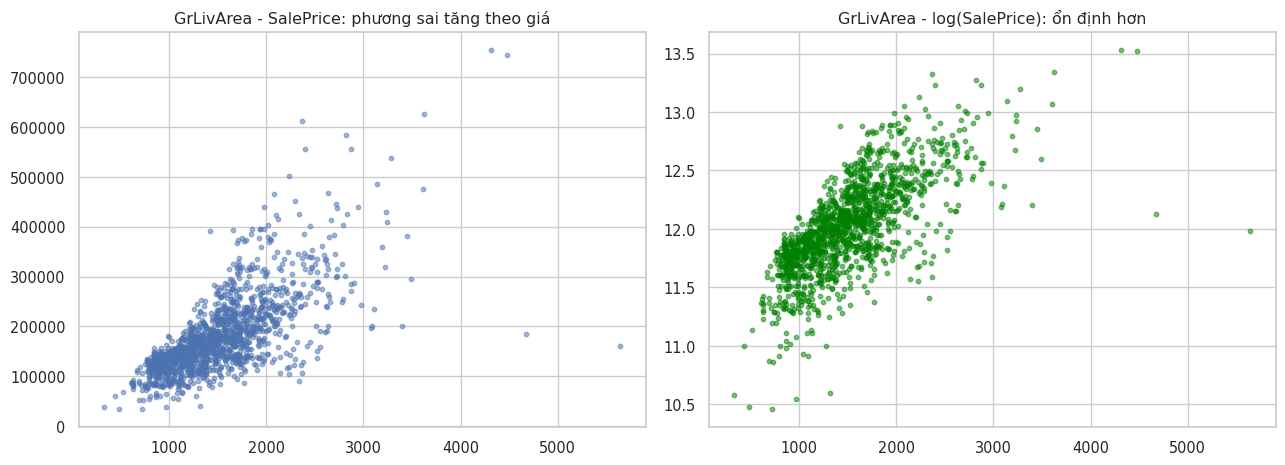

Spearman > Pearson (gợi ý phi tuyến/đơn điệu):
LotArea        0.193
OpenPorchSF    0.162
YearBuilt      0.130
GarageYrBlt    0.107
MSSubClass     0.091
FullBath       0.075


In [5]:
sc = ['GrLivArea','TotalBsmtSF','GarageArea','1stFlrSF','LotArea','YearBuilt']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for a, c in zip(axes.ravel(), sc):
    sns.regplot(data=train, x=c, y='SalePrice', ax=a, scatter_kws={'alpha': .35, 's': 12}, line_kws={'color': 'red'}, lowess=False); a.set_title(f'{c} (r={cs[c]:.2f})')
save_fig('03_scatter')
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].scatter(train.GrLivArea, train.SalePrice, s=10, alpha=.5); ax[0].set_title('GrLivArea - SalePrice: phương sai tăng theo giá')
ax[1].scatter(train.GrLivArea, np.log(train.SalePrice), s=10, alpha=.5, color='green'); ax[1].set_title('GrLivArea - log(SalePrice): ổn định hơn')
save_fig('03_hetero')
diff = (sp - cs).sort_values(ascending=False); print('Spearman > Pearson (gợi ý phi tuyến/đơn điệu):'); print(diff.head(6).round(3).to_string())

## 4. Biến phân loại và SalePrice

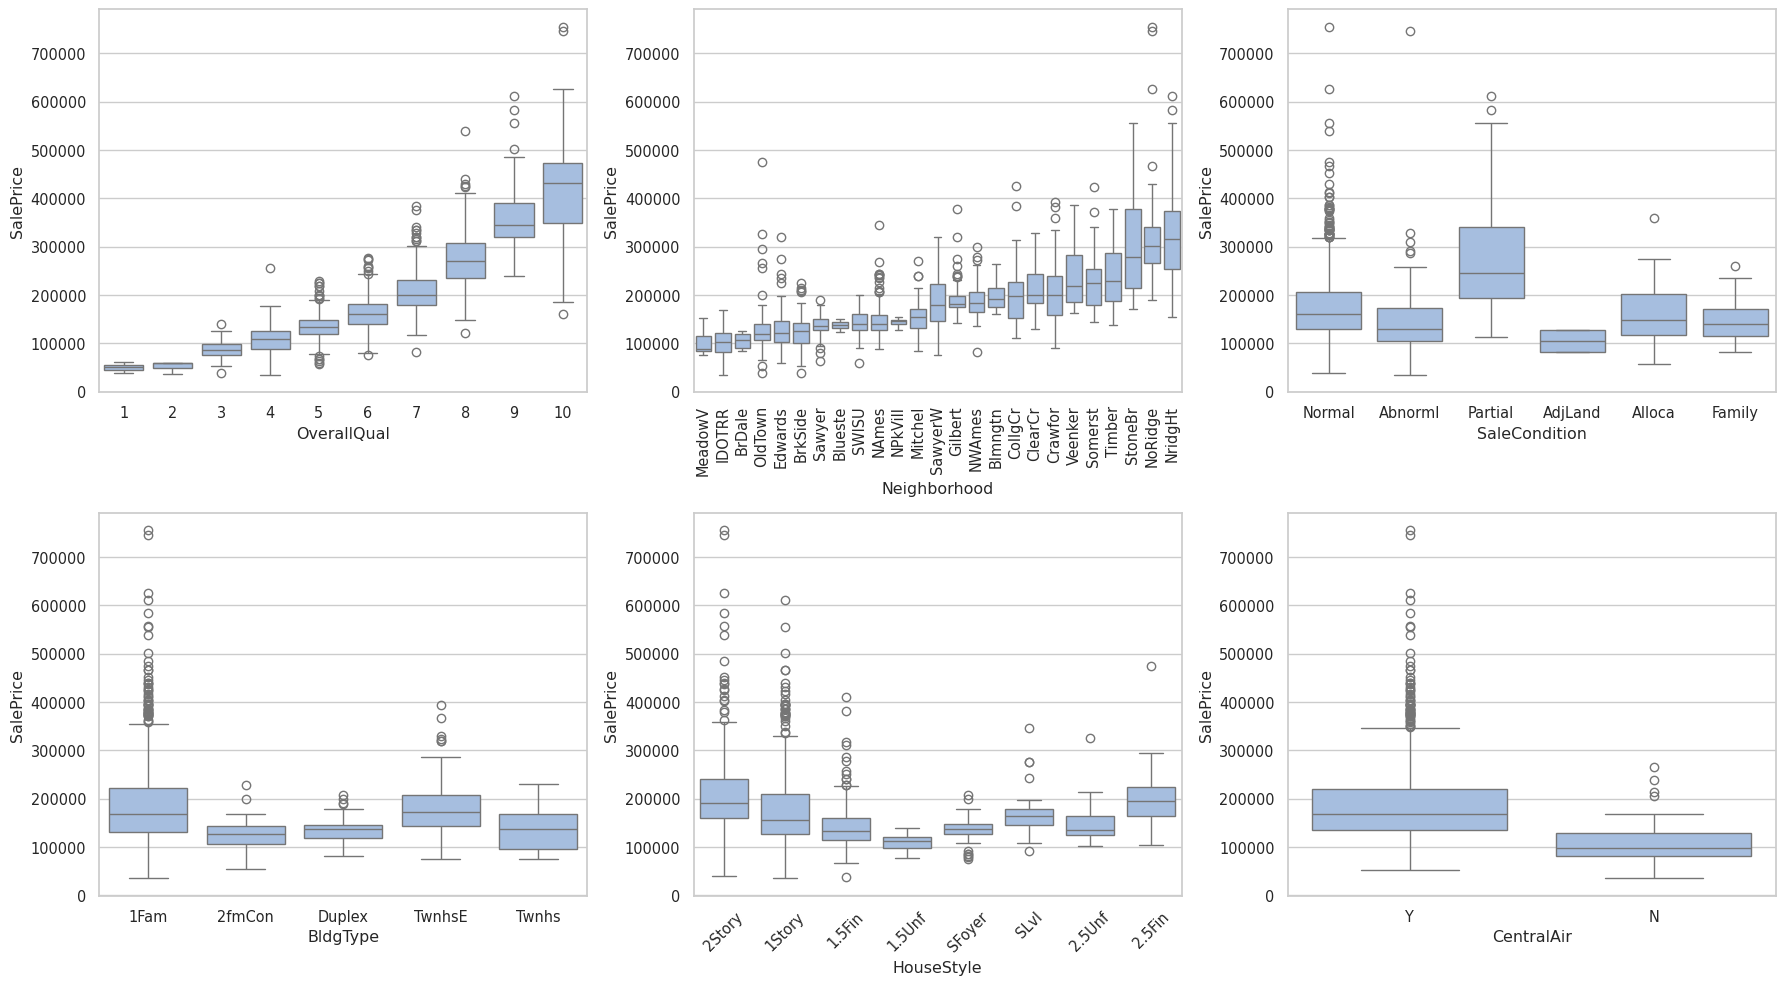

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=axes[0,0], color='#9DBCE8')
o = train.groupby('Neighborhood').SalePrice.median().sort_values().index
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=o, ax=axes[0,1], color='#9DBCE8'); axes[0,1].tick_params(axis='x', rotation=90)
sns.boxplot(data=train, x='SaleCondition', y='SalePrice', ax=axes[0,2], color='#9DBCE8')
sns.boxplot(data=train, x='BldgType', y='SalePrice', ax=axes[1,0], color='#9DBCE8')
sns.boxplot(data=train, x='HouseStyle', y='SalePrice', ax=axes[1,1], color='#9DBCE8'); axes[1,1].tick_params(axis='x', rotation=45)
sns.boxplot(data=train, x='CentralAir', y='SalePrice', ax=axes[1,2], color='#9DBCE8')
save_fig('03_box_cat')

,H,p,eta2_xap_xi
Biến,,,
Neighborhood,868.532,0.0,0.595
ExterQual,683.440,0.0,0.468
KitchenQual,661.482,0.0,0.453
BsmtQual,631.833,0.0,0.433
GarageFinish,505.208,0.0,0.346
Foundation,488.723,0.0,0.335
GarageType,421.155,0.0,0.289
HeatingQC,354.672,0.0,0.243
Exterior1st,298.954,0.0,0.205


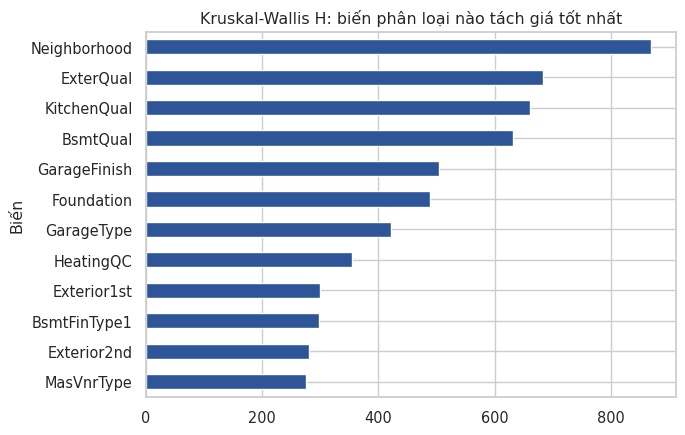

Biến phân loại KHÔNG có ý nghĩa (p>0.05): ['BsmtFinType2', 'LandSlope', 'Street', 'MiscFeature', 'PoolQC']


In [7]:
from scipy import stats
res = []
for c in cats:
    g = [v.SalePrice.values for _, v in train.dropna(subset=[c]).groupby(c) if len(v) > 1]
    if len(g) > 1:
        H_, p = stats.kruskal(*g); res.append((c, H_, p, H_ / (len(train) - 1)))
kw = pd.DataFrame(res, columns=['Biến', 'H', 'p', 'eta2_xap_xi']).sort_values('H', ascending=False).set_index('Biến')
kw.round(4).to_csv(f'{RES}/kruskal_bien_phan_loai.csv', encoding='utf-8-sig'); display(kw.head(10).round(3))
kw.head(12).sort_values('H').H.plot.barh(figsize=(7, 4.5), color='#2E5597', title='Kruskal-Wallis H: biến phân loại nào tách giá tốt nhất')
save_fig('03_kruskal')
print('Biến phân loại KHÔNG có ý nghĩa (p>0.05):', kw[kw.p > 0.05].index.tolist())

## 5. Biến gợi ý từ paper (TotalSF, tuổi nhà, tổng phòng tắm) và Figure 7

TotalSF        0.779
HouseAge      -0.523
TotalBath      0.632
GrLivArea      0.709
OverallQual    0.791
YearBuilt      0.523
FullBath       0.561


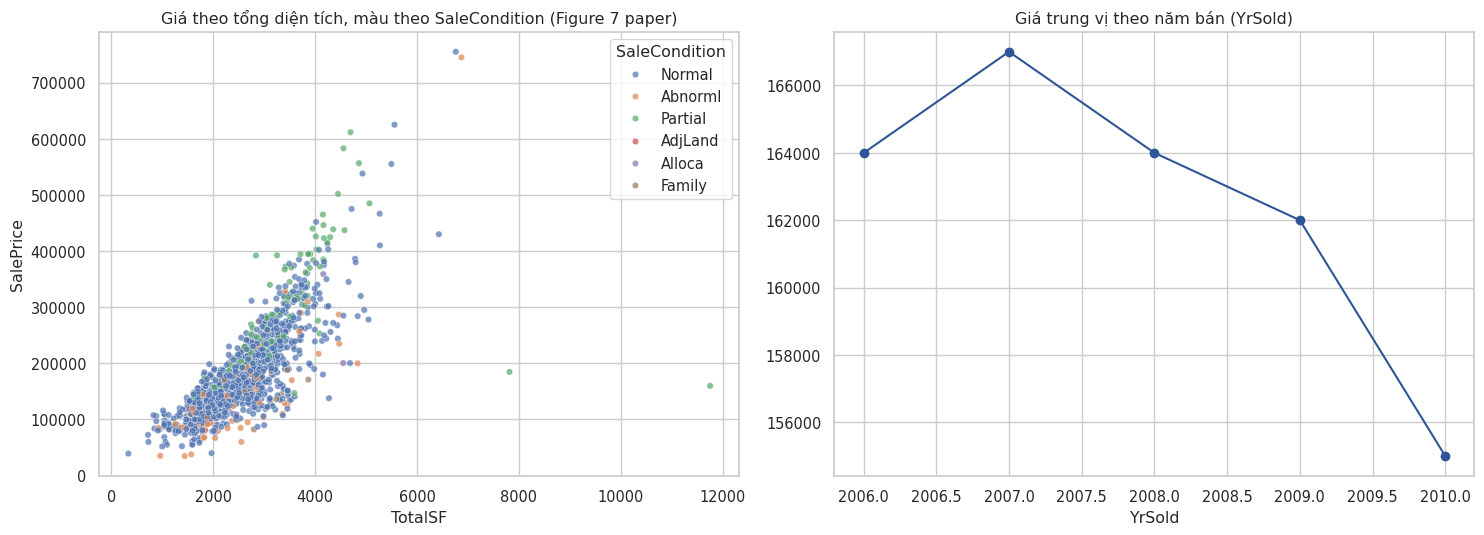

R2: GrLivArea=0.502; TotalSF=0.607; TotalSF+Neighborhood=0.758 (paper: khoảng 0.80)


In [8]:
d = train.copy()
d['TotalSF'] = d.TotalBsmtSF + d.GrLivArea; d['HouseAge'] = d.YrSold - d.YearBuilt
d['TotalBath'] = d.FullBath + 0.5 * d.HalfBath + d.BsmtFullBath + 0.5 * d.BsmtHalfBath
nc = d[['TotalSF','HouseAge','TotalBath','GrLivArea','OverallQual','YearBuilt','FullBath']].corrwith(d.SalePrice).round(3); print(nc.to_string())
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=d, x='TotalSF', y='SalePrice', hue='SaleCondition', ax=ax[0], s=22, alpha=.7); ax[0].set_title('Giá theo tổng diện tích, màu theo SaleCondition (Figure 7 paper)')
d['SalePrice'].groupby(d.YrSold).median().plot(marker='o', ax=ax[1], color='#2E5597'); ax[1].set_title('Giá trung vị theo năm bán (YrSold)')
save_fig('03_totalsf')
m = smf = None
import statsmodels.formula.api as smf
r2_gr = smf.ols('SalePrice ~ GrLivArea', d).fit().rsquared; r2_tot = smf.ols('SalePrice ~ TotalSF', d).fit().rsquared
r2_nb = smf.ols('SalePrice ~ TotalSF + C(Neighborhood)', d).fit().rsquared
print(f'R2: GrLivArea={r2_gr:.3f}; TotalSF={r2_tot:.3f}; TotalSF+Neighborhood={r2_nb:.3f} (paper: khoảng 0.80)')

In [9]:
ex = {'yr_med': train.groupby('YrSold').SalePrice.median().to_dict(), 'vif_all': V.head(10).to_dict()}
print(ex)
save_json('nb03', {**ex, 'top_corr': cs.head(8).round(2).to_dict(), 'neg_corr': cs.tail(2).round(2).to_dict(), 'pairs': pairs, 'vif_top': V.head(6).round(1).replace(np.inf, None).to_dict(),
  'kw_top': kw.head(5).H.round(0).to_dict(), 'kw_ns': kw[kw.p > 0.05].index.tolist(), 'newvars': nc.to_dict(), 'r2': {'GrLivArea': r2_gr, 'TotalSF': r2_tot, 'TotalSF+Neighborhood': r2_nb},
  'spearman_gap': diff.head(4).round(2).to_dict(), 'neigh_med_hi': train.groupby('Neighborhood').SalePrice.median().sort_values().tail(3).to_dict(),
  'neigh_med_lo': train.groupby('Neighborhood').SalePrice.median().sort_values().head(3).to_dict(), 'salecond_med': train.groupby('SaleCondition').SalePrice.median().to_dict()})

{'yr_med': {2006: 163995.0, 2007: 167000.0, 2008: 164000.0, 2009: 162000.0, 2010: 155000.0}, 'vif_all': {'BsmtFinSF1': 1000799917193443.5, 'BsmtUnfSF': 1000799917193443.5, 'BsmtFinSF2': 1000799917193443.5, 'LowQualFinSF': 1000799917193443.5, '2ndFlrSF': 1000799917193443.5, '1stFlrSF': 1000799917193443.5, 'GrLivArea': 1000799917193443.5, 'TotalBsmtSF': 1000799917193443.5, 'GarageCars': 5.495028754493509, 'GarageArea': 5.231135160761888}}
